In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

from sklearn.dummy import DummyClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import SGDClassifier, Perceptron, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
import json
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from cbb.lib.paths import M_TOR_TRAIN_ALL
torvik_men = [
    "Rk",
    "Team",
    "Seed",
    "Finish",
    "Tourney",
    "Year",
    "Conf",
    "G",
    "Rec",
    "AdjOE",
    "AdjDE",
    "Barthag",
    "EFG%",
    "EFGD%",
    "TOR",
    "TORD",
    "ORB",
    "DRB",
    "FTR",
    "FTRD",
    "2P%",
    "2P%D",
    "3P%",
    "3P%D",
    "3PR",
    "3PRD",
    "Adj T.",
    "WAB",
]
filename = M_TOR_TRAIN_ALL
try:
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.loads(json.load(f))
        df = pd.DataFrame(data)
        print(f"Data successfully loaded from {filename}")
except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {filename}: {e}")
except IOError as e:
        print(f"Error loading data from {filename}: {e}")

Data successfully loaded from /workspaces/cbb-model/model_data/torvik/torvik_all.json


In [2]:
X = df.drop(
    columns=[
        "TOURNEY",
        "TEAM",
        "CONF",
        "YEAR",
        "SEED",
        "POSTSEASON",
        "G",
        "WAB",
        "W"
    ]
)
y = df["TOURNEY"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = LogisticRegression(max_iter=10000, solver="liblinear")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.89


In [3]:
# Coefficients and Odds Ratios
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)


# Display feature importance using coefficients and odds ratios
feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": coefficients, "Odds Ratio": odds_ratios}
)
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by="Coefficient", ascending=False))


Feature Importance (Coefficient and Odds Ratio):
    Feature  Coefficient  Odds Ratio
3     EFG_O     0.567122    1.763185
12     2P_D     0.413741    1.512465
14     3P_D     0.228198    1.256334
6      TORD     0.209677    1.233280
0     ADJOE     0.165799    1.180336
7       ORB     0.115084    1.121968
9       FTR     0.084168    1.087811
15    ADJ_T     0.013403    1.013493
10     FTRD    -0.049997    0.951232
8       DRB    -0.071878    0.930645
13     3P_O    -0.133540    0.874993
11     2P_O    -0.212141    0.808851
1     ADJDE    -0.223437    0.799766
5       TOR    -0.304152    0.737749
4     EFG_D    -0.763905    0.465844
2   BARTHAG    -3.087844    0.045600


In [4]:
# Permutation Importance
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance Mean": perm_importance.importances_mean,
        "Importance Std": perm_importance.importances_std,
    }
)
print("\nPermutation Importance:")
print(perm_importance_df.sort_values(by="Importance Mean", ascending=False))


Permutation Importance:
    Feature  Importance Mean  Importance Std
4     EFG_D         0.115009        0.009520
3     EFG_O         0.067982        0.006928
1     ADJDE         0.052802        0.006297
12     2P_D         0.047799        0.008151
0     ADJOE         0.043596        0.007291
2   BARTHAG         0.023528        0.005149
11     2P_O         0.021670        0.005093
14     3P_D         0.015037        0.003776
5       TOR         0.009663        0.005015
13     3P_O         0.005346        0.003965
6      TORD         0.004517        0.003401
7       ORB         0.003573        0.003887
9       FTR         0.002516        0.003998
15    ADJ_T         0.002373        0.001246
8       DRB         0.000943        0.003747
10     FTRD        -0.000600        0.002704


In [5]:
# Recursive Feature Elimination (RFE)
# 1. Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Logistic model with higher iterations
rfe_model = LogisticRegression(max_iter=5000, solver="lbfgs")

# 3. RFE
rfe = RFE(rfe_model, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# 4. Get feature names
rfe_features = X_train.columns[rfe.support_]

print("\nSelected Features by RFE:")
print(rfe_features)


Selected Features by RFE:
Index(['ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB',
       'FTR', '2P_D'],
      dtype='object')


In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy  # Requires: pip install boruta

# 1. SETUP - Aiming for top 10 features across all methods
n_select = 10
votes = pd.DataFrame({"Feature": X.columns})

# 2. FILTER METHODS (Statistical)
# ANOVA F-Value
skb = SelectKBest(f_classif, k=n_select).fit(X, y)
votes["SelectKBest"] = skb.get_support()

# Mutual Information (Captures non-linear dependencies)
mi = SelectKBest(mutual_info_classif, k=n_select).fit(X, y)
votes["Mutual_Info"] = mi.get_support()

# 3. WRAPPER METHODS (Iterative)
# RFE with Logistic Regression
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=n_select).fit(X, y)
votes["RFE"] = rfe.support_

# Boruta (Proves features are better than random shadow noise)
rf_boruta = RandomForestClassifier(n_jobs=-1, max_depth=5)
boruta = BorutaPy(rf_boruta, n_estimators="auto", verbose=0).fit(X.values, y.values)
votes["Boruta"] = boruta.support_

# 4. EMBEDDED METHODS (Model-Specific)
# Lasso (L1 Regularization - forces weak coefficients to zero)
lasso = LogisticRegression(penalty="l1", solver="liblinear", C=0.2).fit(X, y)
lasso_top = np.argsort(abs(lasso.coef_[0]))[-n_select:]
votes["Lasso_L1"] = [i in lasso_top for i in range(len(X.columns))]

# Random Forest Importance (Tree-based impurity reduction)
rf = RandomForestClassifier(n_estimators=100).fit(X, y)
rf_top = np.argsort(rf.feature_importances_)[-n_select:]
votes["RandomForest"] = [i in rf_top for i in range(len(X.columns))]

# 5. FINAL TALLY
votes["Total_Votes"] = votes.iloc[:, 1:].sum(axis=1)
# Filter for features selected by at least 3 methods
consensus_features = votes[votes["Total_Votes"] >= 3].sort_values(
    by="Total_Votes", ascending=False
)

print(consensus_features[["Feature", "Total_Votes"]])

    Feature  Total_Votes
0     ADJOE            6
1     ADJDE            6
2   BARTHAG            6
3     EFG_O            6
4     EFG_D            6
5       TOR            6
7       ORB            5
14     3P_D            5
11     2P_O            4
12     2P_D            4
13     3P_O            4
6      TORD            3


In [7]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Isolate the Consensus Features
# Assuming 'consensus_features' is the list of names from the previous step
X_final = X[consensus_features["Feature"]]

# 2. Re-split and Scale
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Fit the Final Model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_scaled, y_train)

# 4. Generate Predictions
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[
    :, 1
]  # Probability of being a '1' (In Tourney)

# 5. Print Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.92      0.96      0.94       786
        True       0.80      0.65      0.71       186

    accuracy                           0.90       972
   macro avg       0.86      0.80      0.83       972
weighted avg       0.90      0.90      0.90       972

ROC-AUC Score: 0.9301


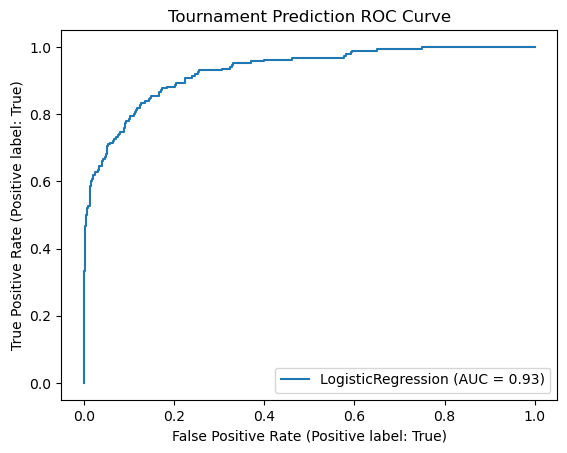

In [8]:
RocCurveDisplay.from_estimator(final_model, X_test_scaled, y_test)
plt.title("Tournament Prediction ROC Curve")
plt.show()

In [9]:
import time


def get_classifier_best(Classifier, X, y, tune=None, **params):
    print("Training classifier '{}'...".format(Classifier.__name__))
    start_time = time.time()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=13, shuffle=True
    )
    clf = Classifier(**params)
    best_score = 0

    if tune:
        search = GridSearchCV(clf, tune, refit=True, n_jobs=-1)
        search.fit(X_train, y_train)

        best_params = search.best_params_
        best_score = search.best_score_
        print(
            "{} scores: {}\twith {}".format(
                Classifier.__name__, best_score, best_params
            )
        )
        clf = search.best_estimator_
    else:
        cv_results = cross_validate(clf, X, y, cv=5)
        scores = cv_results["test_score"]
        best_score = np.mean(scores)
        print(
            "{} scores: {} ± {}".format(Classifier.__name__, best_score, np.std(scores))
        )

        clf.fit(X_train, y_train)
    if hasattr(clf, "feature_importances_") and hasattr(clf, "feature_names_in_"):
        importances = sorted(
            zip(clf.feature_names_in_, clf.feature_importances_),
            key=lambda x: x[1],
            reverse=True,
        )
        print("Feature Importances: {}".format(importances))
    duration = time.time() - start_time
    print(f"⏱️ {Classifier.__name__} took {duration:.2f} seconds")
    return clf, best_score

In [11]:
# run ML models
models = []

tune_params = [{"strategy": ["uniform"], "random_state": [13]}]
result = get_classifier_best(DummyClassifier, X, y, tune=None, strategy="uniform")
models.append(result)

print()
tune_params = {
    "C": np.logspace(-3, 2, 10),  # much better coverage
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"],
    "max_iter": [10000],
}

result = get_classifier_best(LogisticRegression, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": [None, "sqrt"],
}

tune_params = {
    "n_estimators": [100, 300],          # Extremes often tell you which direction to go
    "learning_rate": [0.05, 0.1],        # 0.01 is often too slow for initial tuning
    "max_depth": [3, 4],                 # GBTs usually perform best with shallow trees
    "min_samples_leaf": [1, 5],          # More impactful than min_samples_split
    "subsample": [0.8, 1.0],             # 0.6 is often too aggressive for small datasets
    "max_features": [None, "sqrt"],      # Important for decorrelating trees
}
result = get_classifier_best(GradientBoostingClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "learning_rate": [0.01, 0.03, 0.05],
    "max_iter": [100, 200, 400],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [20, 40, 80],
    "l2_regularization": [0.0, 0.1, 1.0],
}
tune_params = {
    "learning_rate": [0.01, 0.1],      # Move 0.1 into the mix; 0.03/0.05 are often too similar
    "max_iter": [100, 400],           # Focus on low vs high capacity
    "max_depth": [3, None],           # Shallow vs. deep (unconstrained)
    "min_samples_leaf": [20, 80],     # High vs. low regularization
    "l2_regularization": [0.0, 1.0],  # No reg vs. strong reg
}
result = get_classifier_best(HistGradientBoostingClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "C": np.logspace(-3, 2, 8),
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"],
}
result = get_classifier_best(SVC, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "loss": ["log_loss", "modified_huber"],
    "alpha": np.logspace(-5, -2, 5),
    "penalty": ["l2", "l1"],
    "max_iter": [5000],
    "class_weight": [None, "balanced"],
}
result = get_classifier_best(SGDClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(GaussianNB, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(Perceptron, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1],
}
result = get_classifier_best(AdaBoostClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "n_neighbors": [5, 11, 21, 31],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
    "metric": ["minkowski"],
}
result = get_classifier_best(KNeighborsClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "ccp_alpha": [0.0, 0.001, 0.01],
}
result = get_classifier_best(DecisionTreeClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    "n_estimators": [150, 400],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 8],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True],
    "class_weight": [None, "balanced"],
}
tune_params = {
    "n_estimators": [100],            # Constant during tuning; increase later
    "max_depth": [10, 20],            # Avoids 'None' which is slow
    "min_samples_leaf": [1, 5],       # Efficiently controls overfitting
    "max_features": ["sqrt"],         # Best balance of speed and accuracy
    "class_weight": [None, "balanced"] # Only if your classes are imbalanced
}
result = get_classifier_best(RandomForestClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {"max_iter_predict": [10, 100, 200]}
result = get_classifier_best(GaussianProcessClassifier, X, y, tune=tune_params)
models.append(result)

best_model, best_score = max(models, key=lambda x: x[1])
print(
    "\nSelecting '{}' as best model with score: {}".format(
        best_model.__class__.__name__, best_score
    )
)

Training classifier 'DummyClassifier'...
DummyClassifier scores: 0.5088803088803089 ± 0.012833926241768767
⏱️ DummyClassifier took 0.01 seconds

Training classifier 'LogisticRegression'...


LogisticRegression scores: 0.9011376161930528	with {'C': 100.0, 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
⏱️ LogisticRegression took 16.97 seconds

Training classifier 'GradientBoostingClassifier'...
GradientBoostingClassifier scores: 0.9025098288860203	with {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100, 'subsample': 0.8}
Feature Importances: [('ADJOE', 0.2706658899947383), ('BARTHAG', 0.24647493635139706), ('ADJDE', 0.14943966534356373), ('EFG_O', 0.06844974537004112), ('EFG_D', 0.05826020863918709), ('2P_O', 0.030927044931467643), ('TOR', 0.028828191784883786), ('3P_D', 0.023968886247531223), ('3P_O', 0.022561205211179283), ('TORD', 0.019773591399025722), ('FTR', 0.019120627998749008), ('2P_D', 0.015132850038080894), ('ORB', 0.012447348793004222), ('ADJ_T', 0.012254368560946773), ('DRB', 0.010992784283113512), ('FTRD', 0.010702655053090617)]
⏱️ GradientBoostingClassifier took 201.88 seconds

/opt/conda/envs/cbb-env/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDClassifier scores: 0.8863763092901393	with {'alpha': 0.01, 'class_weight': None, 'loss': 'log_loss', 'max_iter': 5000, 'penalty': 'l1'}
⏱️ SGDClassifier took 4.82 seconds

Training classifier 'GaussianNB'...
GaussianNB scores: 0.8380952380952381 ± 0.021983247848438775
⏱️ GaussianNB took 0.02 seconds

Training classifier 'Perceptron'...
Perceptron scores: 0.8167310167310168 ± 0.05200886695172063
⏱️ Perceptron took 0.04 seconds

Training classifier 'AdaBoostClassifier'...
AdaBoostClassifier scores: 0.9001037411657913	with {'learning_rate': 0.1, 'n_estimators': 200}
Feature Importances: [('BARTHAG', 0.17), ('FTR', 0.13), ('TOR', 0.1), ('3P_D', 0.095), ('EFG_O', 0.09), ('TORD', 0.085), ('EFG_D', 0.08), ('3P_O', 0.08), ('ORB', 0.05), ('FTRD', 0.05), ('ADJDE', 0.03), ('2P_O', 0.015), ('DRB', 0.01), ('ADJ_T', 0.01), ('ADJOE', 0.005), ('2P_D', 0.0)]
⏱️ AdaBoostClassifier took 26.38 seconds

Training classifier 'KNeighborsClassifier'...
KNeighborsClassifier scores: 0.8935827836819861	with {'

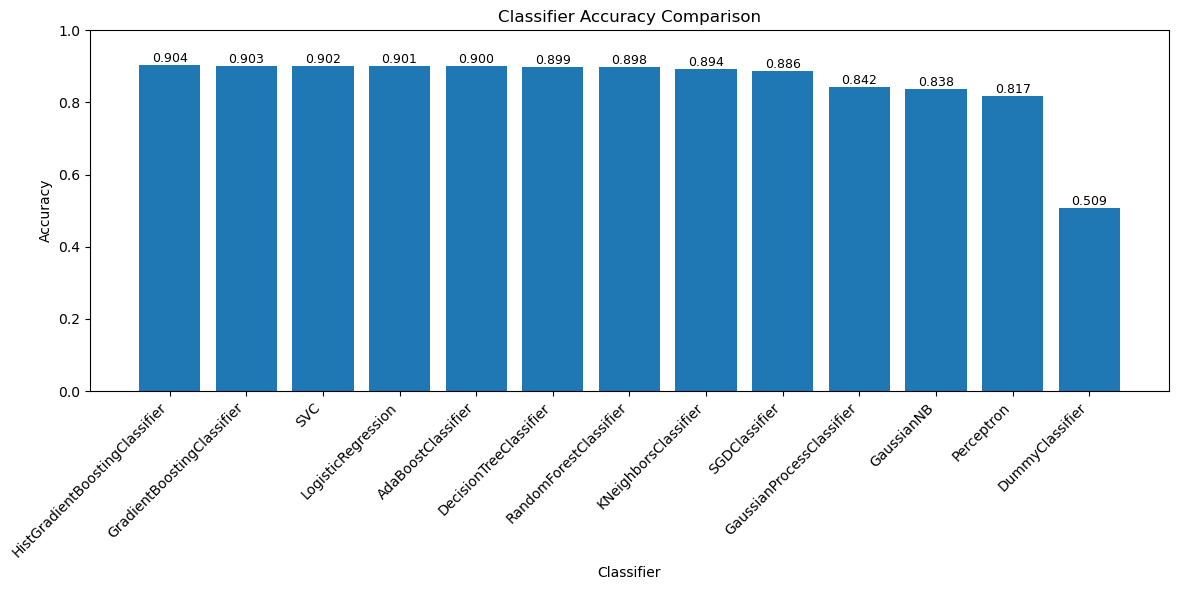

In [12]:
import matplotlib.pyplot as plt

models_sorted = sorted(models, key=lambda x: x[1], reverse=True)

model_names = [m.__class__.__name__ for m, s in models_sorted]
scores = [s for m, s in models_sorted]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, scores)

# Optional: show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.title("Classifier Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)  # assuming accuracy
plt.tight_layout()
plt.show()

SVC, GradientBoostingClassifier, Logistic Regression
https://chatgpt.com/share/697c3918-7494-8005-a060-587f1a0b7775